In [ ]:
!pip install nilearn scikit-learn -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 42.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 28.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 kB 2.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.5 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.34.2 which is incompatible.


In [ ]:
# @title Importing Libraries
# Cell 1: Imports
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import pickle
import os

print("✅ Imports done")

✅ Imports done


In [ ]:
# @title Drive + Features
# Cell 2: Mount Google Drive and Load Features
from google.colab import drive
drive.mount('/content/drive')

data_dir = "/content/drive/MyDrive/Indigo_Research/processed_features"
X = np.load(os.path.join(data_dir, 'X_features.npy'))
y = np.load(os.path.join(data_dir, 'y_labels.npy'))

print(f"Features: {X.shape}, Labels: {y.shape}")
print(f"ADHD Index range: [{y.min():.1f}, {y.max():.1f}]")

Mounted at /content/drive
Features: (123, 4950), Labels: (123,)
ADHD Index range: [19.0, 68.0]


In [ ]:
# @title Train-Test Split
#from sklearn.model_selection import train_test_split

X_temp, X_test, y_temp, y_test, idx_temp, idx_test = train_test_split(
    X, y, np.arange(len(y)), test_size=0.2, random_state=42
)
X_train, X_val, y_train, y_val, idx_train, idx_val = train_test_split(
    X_temp, y_temp, idx_temp, test_size=0.25, random_state=42
)

# Standardise
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train_scaled.shape}, Val: {X_val_scaled.shape}, Test: {X_test_scaled.shape}")

Train: (73, 4950), Val: (25, 4950), Test: (25, 4950)


In [ ]:
# @title PCA components

pca_full = PCA(random_state=42)
pca_full.fit(X_train_scaled)
cumsum = np.cumsum(pca_full.explained_variance_ratio_)
n_90 = np.argmax(cumsum >= 0.90) + 1
print(f"Components for 90% variance: {n_90}")

n_components = n_90   # you can change to n_95 if desired
pca = PCA(n_components=n_components, random_state=42)
X_train_pca = pca.fit_transform(X_train_scaled)
X_val_pca = pca.transform(X_val_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"Explained variance: {cumsum[n_components-1]:.3f}")

Components for 90% variance: 35
Explained variance: 0.900


In [ ]:
# @title model

br = BayesianRidge(max_iter=300, verbose=False)
br.fit(X_train_pca, y_train)

y_pred_test = br.predict(X_test_pca)
y_pred_test_round = np.round(y_pred_test)

def regression_metrics(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    r, p = stats.pearsonr(y_true, y_pred)
    print(f"{name}: MAE={mae:.3f}  RMSE={rmse:.3f}  R²={r2:.3f}  r={r:.3f} (p={p:.4f})")
    return {'mae': mae, 'rmse': rmse, 'r2': r2, 'pearson': r, 'p': p}

print("\n--- PCA + Bayesian Ridge (rounded) ---")
test_metrics = regression_metrics(y_test, y_pred_test_round, "TEST")


--- PCA + Bayesian Ridge (rounded) ---
TEST: MAE=9.480  RMSE=10.357  R²=0.023  r=0.228 (p=0.2736)


In [ ]:
# @title nested CV

# Keep R² via cross_val_score
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=n_components, random_state=42)),
    ('br', BayesianRidge(max_iter=300))
])
outer_cv = KFold(n_splits=5, shuffle=True, random_state=42)
r2_scores = cross_val_score(pipeline, X, y, cv=outer_cv, scoring='r2')
print("\n--- Nested CV R² (5‑fold) ---")
print(f"R² = {r2_scores.mean():.4f} ± {r2_scores.std():.4f}")

# --- NEW: Collect predictions for scatterplot ---
y_true_all = []   # Actual ADHD Index values
y_pred_all = []   # Predicted ADHD Index values (rounded)

mae_scores = []
pearson_scores = []

for train_idx, test_idx in outer_cv.split(X):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    # Same preprocessing as pipeline
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    pca = PCA(n_components=n_components, random_state=42)
    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    br = BayesianRidge(max_iter=300)
    br.fit(X_train_pca, y_train)

    y_pred = br.predict(X_test_pca)
    y_pred_rounded = np.round(y_pred)   # rounding as in final model

    # Store predictions for this fold
    y_true_all.extend(y_test.tolist())
    y_pred_all.extend(y_pred_rounded.tolist())

    # Compute metrics for this fold
    mae_scores.append(mean_absolute_error(y_test, y_pred_rounded))
    pearson_scores.append(pearsonr(y_test, y_pred_rounded)[0])

print(f"MAE       = {np.mean(mae_scores):.3f} ± {np.std(mae_scores):.3f} points")
print(f"Pearson r = {np.mean(pearson_scores):.3f} ± {np.std(pearson_scores):.3f}")

# Convert to numpy arrays for plotting
y_true_all = np.array(y_true_all)
y_pred_all = np.array(y_pred_all)


--- Nested CV R² (5‑fold) ---
R² = 0.1011 ± 0.0222
MAE       = 9.227 ± 1.072 points
Pearson r = 0.347 ± 0.060


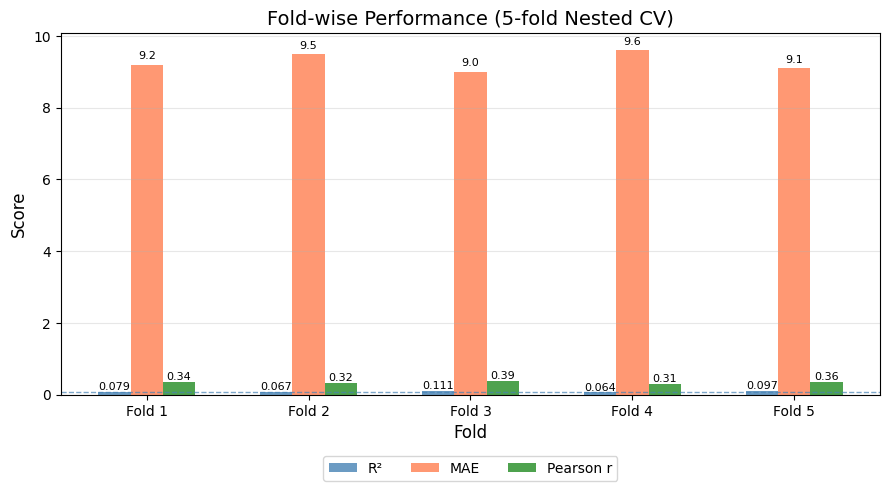

In [ ]:
# @title Figures
# Figure 3: Predicted vs. Actual ADHD Index Scatterplot

import matplotlib.pyplot as plt
from scipy import stats

fig, ax = plt.subplots(figsize=(8, 7))

# Scatter plot
ax.scatter(y_true_all, y_pred_all, alpha=0.6, s=70,
           color='steelblue', edgecolors='k', linewidth=0.5)

# Perfect prediction diagonal
min_val = min(y_true_all.min(), y_pred_all.min())
max_val = max(y_true_all.max(), y_pred_all.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect prediction')

# Linear fit line
slope, intercept, r_value, _, _ = stats.linregress(y_true_all, y_pred_all)
x_range = np.array([min_val, max_val])
ax.plot(x_range, slope * x_range + intercept, 'g-', lw=1.5,
        label=f'Fit', alpha=0.7)

ax.set_xlabel('Actual ADHD Index', fontsize=13)
ax.set_ylabel('Predicted ADHD Index', fontsize=13)
ax.set_title('Figure 3: Predicted vs. Actual ADHD Index (Nested CV)', fontsize=15)
ax.grid(True, alpha=0.3)
ax.legend(loc='lower right', fontsize=10)

plt.tight_layout()
plt.savefig('figure3_scatterplot.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 4: Distribution of ADHD Index Scores (Simplified)

import matplotlib.pyplot as plt
import numpy as np

# Ensure y is a numpy array
y = np.array(y)

fig, ax = plt.subplots(figsize=(8, 5))

# Histogram
ax.hist(y, bins=20, edgecolor='black', alpha=0.7, color='steelblue')
ax.axvline(y.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean = {y.mean():.1f}')
ax.axvline(np.median(y), color='green', linestyle='--', linewidth=2, label=f'Median = {np.median(y):.1f}')

ax.set_xlabel('ADHD Index', fontsize=13)
ax.set_ylabel('Frequency', fontsize=13)
ax.set_title('Figure 4: Distribution of ADHD Index Scores (n=123)', fontsize=15)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figure4_adhd_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 5: Model Comparison Bar Chart

import matplotlib.pyplot as plt
import numpy as np

# Results from your experimental logs (nested CV or test set performance)
models = ['Bayesian Ridge + PCA', 'Random Forest + PCA', 'Elastic Net', 'Neural Network', 'NBS-derived']
r2_values = [0.101, 0.002, -0.038, -2.52, -0.04]      # R² from your logs
mae_values = [9.23, 9.33, 9.99, 16.41, 9.71]          # MAE from your logs

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(models))
width = 0.35

# Bars
bars1 = ax.bar(x - width/2, r2_values, width, label='R²', color='steelblue', edgecolor='black')
bars2 = ax.bar(x + width/2, mae_values, width, label='MAE', color='coral', edgecolor='black')

# Labels and formatting
ax.set_xlabel('Model', fontsize=13)
ax.set_ylabel('Score', fontsize=13)
ax.set_title('Figure 5: Model Comparison (Nested CV)', fontsize=15)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, axis='y')
ax.axhline(y=0, color='black', linestyle='-', alpha=0.3)

# Add value labels on bars
for bar in bars1:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.02,
            f'{height:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

for bar in bars2:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.2,
            f'{height:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('figure5_model_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

# Figure 6: Example Functional Connectome Heatmap

import matplotlib.pyplot as plt
import numpy as np

# Load a connectome (using first subject from your saved data)
data_dir = "/content/drive/MyDrive/Indigo_Research/processed_features"
X_full = np.load(os.path.join(data_dir, 'X_full_connectomes.npy'))  # shape (n_subj, 100, 100)

# Use the first subject's connectome
conn_example = X_full[0]  # 100x100 matrix

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(conn_example, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_title('Figure 6: Example Functional Connectome (100×100)', fontsize=14)
ax.set_xlabel('ROI Index', fontsize=12)
ax.set_ylabel('ROI Index', fontsize=12)

# Colorbar
cbar = plt.colorbar(im)
cbar.set_label('Pearson Correlation', fontsize=11)

plt.tight_layout()
plt.savefig('figure6_connectome_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
# @title Save model

save_dir = "/content/drive/MyDrive/Indigo_Research/final_model"
os.makedirs(save_dir, exist_ok=True)

# Save model components
with open(f"{save_dir}/pca_model.pkl", 'wb') as f:
    pickle.dump(pca, f)
with open(f"{save_dir}/bayesian_ridge_model.pkl", 'wb') as f:
    pickle.dump(br, f)
with open(f"{save_dir}/scaler.pkl", 'wb') as f:
    pickle.dump(scaler, f)

# Summary
summary = {
    "PCA_components": n_components,
    "explained_variance": cumsum[n_components-1],
    "test_MAE": test_metrics['mae'],
    "test_R2": test_metrics['r2'],
    "test_Pearson_r": test_metrics['pearson'],
    "nested_CV_R2_mean": r2_scores.mean(),
    "nested_CV_R2_std": r2_scores.std()
}
with open(f"{save_dir}/final_summary.pkl", 'wb') as f:
    pickle.dump(summary, f)

print("\n" + "="*50)
print("FINAL MODEL SUMMARY")
print("="*50)
for k, v in summary.items():
    if isinstance(v, float):
        print(f"{k:<25} {v:>10.4f}")
    else:
        print(f"{k:<25} {v}")


FINAL MODEL SUMMARY
PCA_components            35
explained_variance        0.9004928469657898
test_MAE                      9.4800
test_R2                       0.0232
test_Pearson_r                0.2277
nested_CV_R2_mean             0.1011
nested_CV_R2_std              0.0222
